In [1]:
import os
os.chdir('..')
import sys
from Controllers.FL import *
from Controllers.ILQG import *
from Controllers.LQGControllers import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec
NUM_SIM = 30
XST = 0
YST = 45
st = [XST,YST]
MovementTime = .4
NumIteration = 40
Time = np.linspace(0,MovementTime*1000,NumIteration)
MN = 1e-3
WP = 100
WV = .05
WR = .1

NUM_SIM = 100
DURATIONS = [.3,.4,.5,.6,.7,.8,.9,1]
DURATIONS_ms = [300,400,500,600,700,800,900,1000]
colors = ["#009E73","#0072B2","#E69F00"]
legend = ["ILQG","FL","DLQG"]

def Compute_Cartesian_Speed(X, Y, dt):
    V = np.zeros(X.shape)
    Vx = np.diff(X) / dt
    Vy = np.diff(Y) / dt
    V[1:] = np.sqrt(Vx * Vx + Vy * Vy)
    return V

d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:452: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:453: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values t

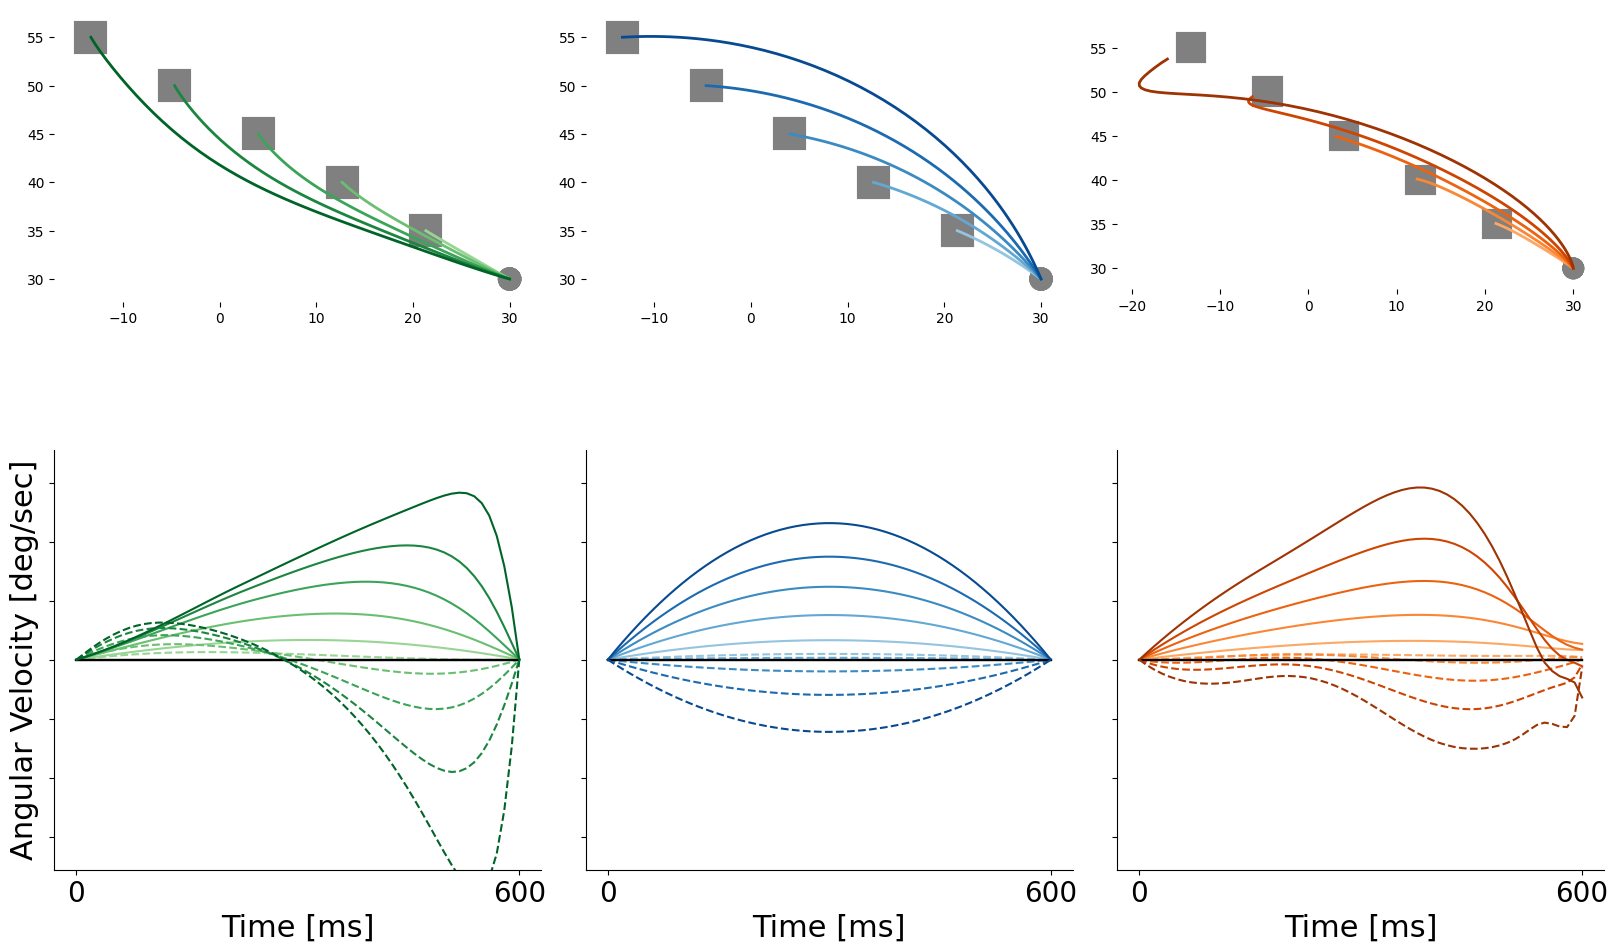

In [66]:
MovementTime = .6
NumIteration = 60
Time = np.linspace(0,MovementTime*1000,NumIteration)

fig= plt.figure(figsize = (20,12))
gs = gridspec.GridSpec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2]) 
ax2 = fig.add_subplot(gs[0, 2:4])  
ax3 = fig.add_subplot(gs[0, 4:6])  


ax41 = fig.add_subplot(gs[1, 0:2])
ax42 = fig.add_subplot(gs[1, 2:4])
ax43 = fig.add_subplot(gs[1, 4:6])

ax40 = np.array([ax41,ax42,ax43])

MV = 1e-3
Velocities = np.zeros((3,2,NumIteration))
greens = [plt.cm.Greens(i) for i in np.linspace(0.4, 0.9, 5)]
blues = [plt.cm.Blues(i) for i in np.linspace(0.4, 0.9, 5)]
oranges = [plt.cm.Oranges(i) for i in np.linspace(0.4, 0.9, 5)]
colors = [greens,blues,oranges]
legend = ["ILQG","FL","DLQG"]
WP = 100
WV = .05
WR = .1
def Cost_function(x,u,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    return WP*(thetas-target1)**2 + WP*(thetae-target2)**2 + WV*(omegas**2+omegae**2)+ np.sum(u*u) *WR * MovementTime/NumIteration

st = np.array([30,30])

ANGLES = np.pi/6

for idx,movement_length in enumerate(np.array([10,20,30,40,50])):

    tg = np.array([st[0]-movement_length*np.cos(ANGLES),st[1]+movement_length*np.sin(ANGLES)])

    xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=False,print_iterations=False,FF =  False,motornoise_variance=MV)
    xFL,yFL,xfl,uFL = simulate_FL(Duration=MovementTime,w1=WP,w2=WP,w3=WV,w4=WV,r=1e-7,Num_iter=NumIteration,starting_point=st,targets=tg,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    xLQG,yLQG,uDLQG,z=DLQG_6Muscles(w1 = WP,w2 = WP,w3 = WV,w4 = WV, Duration=MovementTime,r1 = WR,Num_iter=NumIteration,starting_point=st,targets=tg,plot = False,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    ax1.plot(xILQG,yILQG, color=greens[idx], linewidth=2)
    ax2.plot(xFL,yFL, color=blues[idx], linewidth=2)
    ax3.plot(xLQG,yLQG, color=oranges[idx], linewidth=2)
    Velocities[0] = zilqg[:,2:4].T
    Velocities[1] = xfl[:,2:4].T
    Velocities[2] = z.T[:,2:4].T
        
    Cost_value=[Cost_function(zilqg,uILQG,tg = tg),Cost_function(xfl,uFL,tg = tg),Cost_function(z.T,uDLQG,tg = tg)]

    ax41.set_ylabel("Angular Velocity [deg/sec]" , fontsize = 22)

    for i in range(3):
        ax4 = ax40[i]
        ax4.plot(Time,np.zeros(len(Time)),color = "black")
        mean_vel = Velocities[i,0]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i][idx])

        mean_vel = Velocities[i,1]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i][idx], linestyle = "--")

        delete_axis(ax4,sides = ["top","right"])
        ax4.set_xlabel("Time [ms]" , fontsize = 22)
        ax4.set_xticks([0,600],labels = [0,600],fontsize = 20)
        ax4.set_ylim(-320,320)
        
        ax4.set_yticks([-270,-180,-90,0,90,180,270],labels = ["","","","","","",""],fontsize = 20)


    for ax in [ax1,ax2,ax3]:
        delete_axis(ax)
        ax.set_aspect("equal")
        circle = plt.Circle((st[0],st[1]), 1, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(circle)
        square = plt.Rectangle((tg[0]-1.5,tg[1]-1.5), 3,3, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(square)


plt.show()

d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:452: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:453: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values t

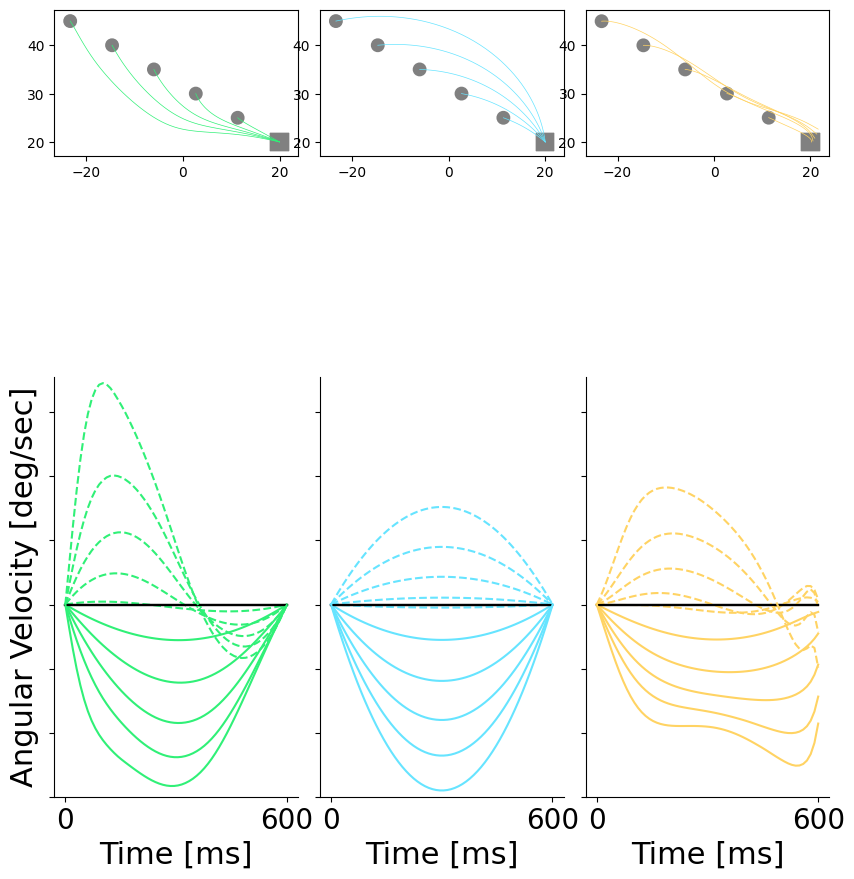

In [44]:
MovementTime = .6
NumIteration = 60
Time = np.linspace(0,MovementTime*1000,NumIteration)

fig= plt.figure(figsize = (10,12))
gs = gridspec.GridSpec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2]) 
ax2 = fig.add_subplot(gs[0, 2:4])  
ax3 = fig.add_subplot(gs[0, 4:6])  


ax41 = fig.add_subplot(gs[1, 0:2])
ax42 = fig.add_subplot(gs[1, 2:4])
ax43 = fig.add_subplot(gs[1, 4:6])

ax40 = np.array([ax41,ax42,ax43])

MV = 1e-3
Velocities = np.zeros((3,2,NumIteration))
colors = ["#30F077","#66E4FF","#FFD363"]
legend = ["ILQG","FL","DLQG"]
WP = 100
WV = .05
WR = .1
def Cost_function(x,u,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    return WP*(thetas-target1)**2 + WP*(thetae-target2)**2 + WV*(omegas**2+omegae**2)+ np.sum(u*u) *WR * MovementTime/NumIteration

st = np.array([20,20])

ANGLES = np.pi/6

for movement_length in np.array([10,20,30,40,50]):

    tg = np.array([st[0]-movement_length*np.cos(ANGLES),st[1]+movement_length*np.sin(ANGLES)])
    xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,st,tg,NumIteration,delay = 0.06,Noise=False,print_iterations=False,FF =  False,motornoise_variance=MV)
    xFL,yFL,xfl,uFL = simulate_FL(Duration=MovementTime,w1=WP,w2=WP,w3=WV,w4=WV,r=1e-7,Num_iter=NumIteration,starting_point=tg,targets=st,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    xLQG,yLQG,uDLQG,z=DLQG_6Muscles(w1 = WP,w2 = WP,w3 = WV,w4 = WV, Duration=MovementTime,r1 = WR,Num_iter=NumIteration,starting_point=tg,targets=st,plot = False,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    ax1.plot(xILQG,yILQG, color=colors[0], linewidth=.5)
    ax2.plot(xFL,yFL, color=colors[1], linewidth=.5)
    ax3.plot(xLQG,yLQG, color=colors[2], linewidth=.5)
    Velocities[0] = zilqg[:,2:4].T
    Velocities[1] = xfl[:,2:4].T
    Velocities[2] = z.T[:,2:4].T
        
    Cost_value=[Cost_function(zilqg,uILQG,tg = tg),Cost_function(xfl,uFL,tg = tg),Cost_function(z.T,uDLQG,tg = tg)]

    ax41.set_ylabel("Angular Velocity [deg/sec]" , fontsize = 22)

    for i in range(3):
        ax4 = ax40[i]
        ax4.plot(Time,np.zeros(len(Time)),color = "black")
        mean_vel = Velocities[i,0]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i])

        mean_vel = Velocities[i,1]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i], linestyle = "--")

        delete_axis(ax4,sides = ["top","right"])
        ax4.set_xlabel("Time [ms]" , fontsize = 22)
        ax4.set_xticks([0,600],labels = [0,600],fontsize = 20)
        ax4.set_ylim(-270,320)
        
        ax4.set_yticks([-270,-180,-90,0,90,180,270],labels = ["","","","","","",""],fontsize = 20)


    for ax in [ax1,ax2,ax3]:
        ax.set_aspect("equal")
        circle = plt.Circle((tg[0],tg[1]), 1, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(circle)
        square = plt.Rectangle((st[0]-1.5,st[1]-1.5), 3,3, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(square)


plt.show()

In [ ]:
MovementTime = .6
NumIteration = 60
Time = np.linspace(0,MovementTime*1000,NumIteration)

fig= plt.figure(figsize = (20,12))
gs = gridspec.GridSpec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2]) 
ax2 = fig.add_subplot(gs[0, 2:4])  
ax3 = fig.add_subplot(gs[0, 4:6])  


ax41 = fig.add_subplot(gs[1, 0:2])
ax42 = fig.add_subplot(gs[1, 2:4])
ax43 = fig.add_subplot(gs[1, 4:6])

ax40 = np.array([ax41,ax42,ax43])

MV = 1e-3
Velocities = np.zeros((3,2,NumIteration))
greens = [plt.cm.Greens(i) for i in np.linspace(0.4, 0.9, 5)]
blues = [plt.cm.Blues(i) for i in np.linspace(0.4, 0.9, 5)]
oranges = [plt.cm.Oranges(i) for i in np.linspace(0.4, 0.9, 5)]
colors = [greens,blues,oranges]
legend = ["ILQG","FL","DLQG"]
WP = 100
WV = .05
WR = .1
def Cost_function(x,u,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    return WP*(thetas-target1)**2 + WP*(thetae-target2)**2 + WV*(omegas**2+omegae**2)+ np.sum(u*u) *WR * MovementTime/NumIteration

st = np.array([-30,30])

ANGLES = np.pi/6

for idx,movement_length in enumerate(np.array([10,20,30,40,50])):

    tg = np.array([st[0]+movement_length*np.cos(ANGLES),st[1]+movement_length*np.sin(ANGLES)])

    xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=False,print_iterations=False,FF =  False,motornoise_variance=MV)
    xFL,yFL,xfl,uFL = simulate_FL(Duration=MovementTime,w1=WP,w2=WP,w3=WV,w4=WV,r=1e-7,Num_iter=NumIteration,starting_point=st,targets=tg,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    xLQG,yLQG,uDLQG,z=DLQG_6Muscles(w1 = WP,w2 = WP,w3 = WV,w4 = WV, Duration=MovementTime,r1 = WR,Num_iter=NumIteration,starting_point=st,targets=tg,plot = False,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    ax1.plot(xILQG,yILQG, color=greens[idx], linewidth=2)
    ax2.plot(xFL,yFL, color=blues[idx], linewidth=2)
    ax3.plot(xLQG,yLQG, color=oranges[idx], linewidth=2)
    Velocities[0] = zilqg[:,2:4].T
    Velocities[1] = xfl[:,2:4].T
    Velocities[2] = z.T[:,2:4].T
        
    Cost_value=[Cost_function(zilqg,uILQG,tg = tg),Cost_function(xfl,uFL,tg = tg),Cost_function(z.T,uDLQG,tg = tg)]

    ax41.set_ylabel("Angular Velocity [deg/sec]" , fontsize = 22)

    for i in range(3):
        ax4 = ax40[i]
        ax4.plot(Time,np.zeros(len(Time)),color = "black")
        mean_vel = Velocities[i,0]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i][idx])

        mean_vel = Velocities[i,1]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i][idx], linestyle = "--")

        delete_axis(ax4,sides = ["top","right"])
        ax4.set_xlabel("Time [ms]" , fontsize = 22)
        ax4.set_xticks([0,600],labels = [0,600],fontsize = 20)
        ax4.set_ylim(-320,320)
        
        ax4.set_yticks([-270,-180,-90,0,90,180,270],labels = ["","","","","","",""],fontsize = 20)


    for ax in [ax1,ax2,ax3]:
        delete_axis(ax)
        ax.set_aspect("equal")
        circle = plt.Circle((st[0],st[1]), 1, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(circle)
        square = plt.Rectangle((tg[0]-1.5,tg[1]-1.5), 3,3, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(square)


plt.show()

d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:452: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:453: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values t

d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:452: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:453: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:455: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:456: ComplexWarning: Casting complex values to real discards the imaginary part
  L[k] = -Hinv @ G
d:\thyriona\Desktop\Codes\FL\PhD\Controllers\ILQG.py:451: ComplexWarning: Casting complex values t

LinAlgError: Array must not contain infs or NaNs

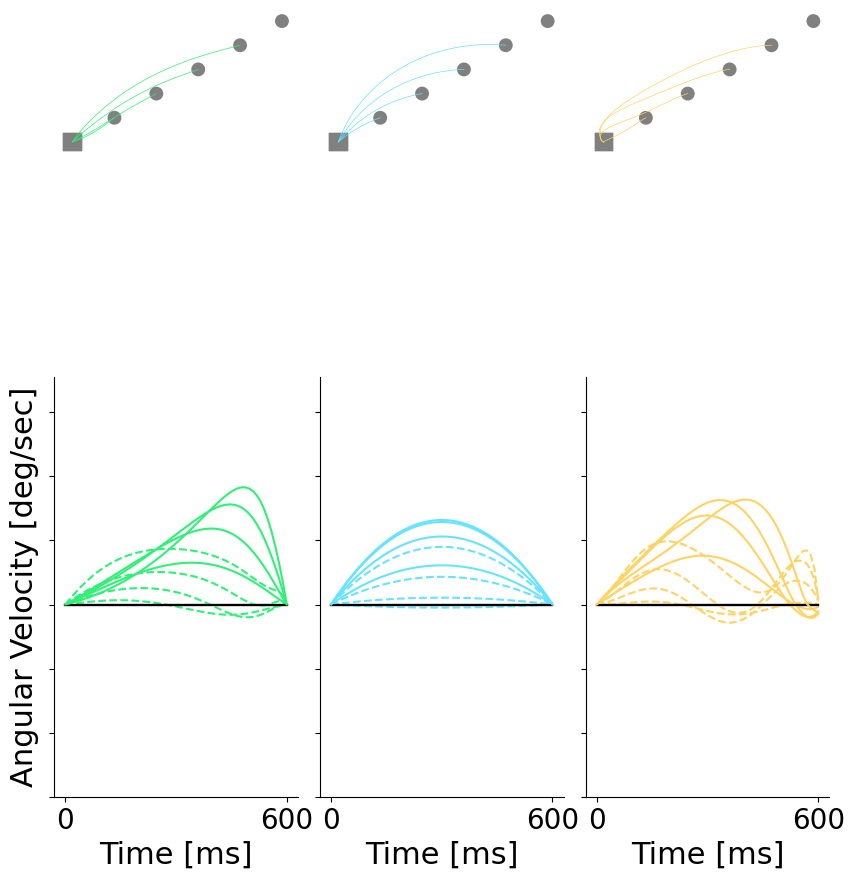

In [46]:
MovementTime = .6
NumIteration = 60
Time = np.linspace(0,MovementTime*1000,NumIteration)

fig= plt.figure(figsize = (10,12))
gs = gridspec.GridSpec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2]) 
ax2 = fig.add_subplot(gs[0, 2:4])  
ax3 = fig.add_subplot(gs[0, 4:6])  


ax41 = fig.add_subplot(gs[1, 0:2])
ax42 = fig.add_subplot(gs[1, 2:4])
ax43 = fig.add_subplot(gs[1, 4:6])

ax40 = np.array([ax41,ax42,ax43])

MV = 1e-3
Velocities = np.zeros((3,2,NumIteration))
colors = ["#30F077","#66E4FF","#FFD363"]
legend = ["ILQG","FL","DLQG"]
WP = 100
WV = .05
WR = .1
def Cost_function(x,u,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    return WP*(thetas-target1)**2 + WP*(thetae-target2)**2 + WV*(omegas**2+omegae**2)+ np.sum(u*u) *WR * MovementTime/NumIteration

st = np.array([-20,20])

ANGLES = np.pi/6

for movement_length in np.array([10,20,30,40,50]):

    tg = np.array([st[0]+movement_length*np.cos(ANGLES),st[1]+movement_length*np.sin(ANGLES)])
    for ax in [ax1,ax2,ax3]:
        ax.set_aspect("equal")
        ax.set_yticks([])
        ax.set_xticks([])
        delete_axis(ax)
        circle = plt.Circle((tg[0],tg[1]), 1, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(circle)
        square = plt.Rectangle((st[0]-1.5,st[1]-1.5), 3,3, edgecolor='grey',facecolor = "grey", linewidth=3)
        ax.add_patch(square)

    xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,st,tg,NumIteration,delay = 0.06,Noise=False,print_iterations=False,FF =  False,motornoise_variance=MV)
    xFL,yFL,xfl,uFL = simulate_FL(Duration=MovementTime,w1=WP,w2=WP,w3=WV,w4=WV,r=1e-7,Num_iter=NumIteration,starting_point=tg,targets=st,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    xLQG,yLQG,uDLQG,z=DLQG_6Muscles(w1 = WP,w2 = WP,w3 = WV,w4 = WV, Duration=MovementTime,r1 = WR,Num_iter=NumIteration,starting_point=tg,targets=st,plot = False,Delay = 0.06,Activate_Noise=False,FF = False,motornoise_variance=MV)
    ax1.plot(xILQG,yILQG, color=colors[0], linewidth=.5)
    ax2.plot(xFL,yFL, color=colors[1], linewidth=.5)
    ax3.plot(xLQG,yLQG, color=colors[2], linewidth=.5)
    Velocities[0] = zilqg[:,2:4].T
    Velocities[1] = xfl[:,2:4].T
    Velocities[2] = z.T[:,2:4].T
        
    Cost_value=[Cost_function(zilqg,uILQG,tg = tg),Cost_function(xfl,uFL,tg = tg),Cost_function(z.T,uDLQG,tg = tg)]

    ax41.set_ylabel("Angular Velocity [deg/sec]" , fontsize = 22)

    for i in range(3):
        ax4 = ax40[i]
        ax4.plot(Time,np.zeros(len(Time)),color = "black")
        mean_vel = Velocities[i,0]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i])

        mean_vel = Velocities[i,1]*180/pi

        ax4.plot(Time, mean_vel, color=colors[i], linestyle = "--")

        delete_axis(ax4,sides = ["top","right"])
        ax4.set_xlabel("Time [ms]" , fontsize = 22)
        ax4.set_xticks([0,600],labels = [0,600],fontsize = 20)
        ax4.set_ylim(-270,320)
        
        ax4.set_yticks([-270,-180,-90,0,90,180,270],labels = ["","","","","","",""],fontsize = 20)





plt.show()